# Object Detection with Street View House Numbers

This notebook illustrates how to build a deep CNN using Keras’ functional API to generate multiple outputs: one to predict how many digits are present, and five for the value of each in the order they appear.

## Imports & Settings

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import (
    Flatten,
    Dense,
    BatchNormalization,
    Activation,
    Concatenate,
)
from tensorflow.keras import backend as K
from matplotlib.ticker import FuncFormatter

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [3]:
sns.set_style("whitegrid")

In [4]:
data_path = Path("images", "svhn")

In [5]:
results_path = Path("results", "svhn")
if not results_path.exists():
    results_path.mkdir()

### Settings

In [6]:
IMG_SIZE = 32
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
SEQ_LENGTH = 4
N_CLASSES = 11

## Load Data 

In [7]:
X_train = np.load(data_path / "X_train.npy")
y_train = np.load(data_path / "y_train.npy")

Removing the rare cases of 5-digit house numbers.

In [8]:
X_train = X_train[y_train[:, 0] < 5]
y_train = y_train[y_train[:, 0] < 5, :5]
y_train[:, 0] -= 1

In [9]:
X_test = np.load(data_path / "X_test.npy")
y_test = np.load(data_path / "y_test.npy")

In [10]:
X_test = X_test[y_test[:, 0] < 5]
y_test = y_test[y_test[:, 0] < 5, :5]
y_test[:, 0] -= 1

In [11]:
pd.DataFrame(y_train).nunique()

0     4
1    10
2    11
3    11
4    11
dtype: int64

In [12]:
y_train.shape

(33392, 5)

## Best Architecture

[Multi-digit Number Recognition from Street View Imagery using Deep Convolutional Neural Networks](https://arxiv.org/abs/1312.6082), Goodfellow, et al, 2014

In [13]:
digit_pos = {1: [4, 14], 2: [14, 25], 3: [25, 36], 4: [36, 47]}

In [14]:
def weighted_accuracy(y_true, y_pred):
    n_digits_pred = K.argmax(y_pred[:, :SEQ_LENGTH], axis=1)

    digit_preds = {}
    for digit, (start, end) in digit_pos.items():
        digit_preds[digit] = K.argmax(y_pred[:, start:end], axis=1)
    preds = tf.dtypes.cast(
        tf.stack(
            (
                n_digits_pred,
                digit_preds[1],
                digit_preds[2],
                digit_preds[3],
                digit_preds[4],
            ),
            axis=1,
        ),
        tf.float32,
    )
    y_true = tf.cast(y_true, preds.dtype)
    return K.mean(K.sum(tf.dtypes.cast(K.equal(y_true, preds), tf.int64), axis=1) / 5)

In [15]:
def weighted_entropy(y_true, y_pred):
    cce = tf.keras.losses.SparseCategoricalCrossentropy()
    n_digits = y_pred[:, :SEQ_LENGTH]

    digits = {}
    for digit, (start, end) in digit_pos.items():
        digits[digit] = y_pred[:, start:end]
    return (
        cce(y_true[:, 0], n_digits)
        + cce(y_true[:, 1], digits[1])
        + cce(y_true[:, 2], digits[2])
        + cce(y_true[:, 3], digits[3])
        + cce(y_true[:, 4], digits[4])
    ) / 5

In [16]:
vgg16 = VGG16(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
vgg16.trainable = False
x = vgg16.output
x = Flatten()(x)
x = BatchNormalization()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
n_digits = Dense(SEQ_LENGTH, activation="softmax", name="n_digits")(x)
digit1 = Dense(N_CLASSES - 1, activation="softmax", name="d1")(x)
digit2 = Dense(N_CLASSES, activation="softmax", name="d2")(x)
digit3 = Dense(N_CLASSES, activation="softmax", name="d3")(x)
digit4 = Dense(N_CLASSES, activation="softmax", name="d4")(x)
predictions = Concatenate()([n_digits, digit1, digit2, digit3, digit4])

model = Model(inputs=vgg16.input, outputs=predictions)

In [17]:
model.compile(optimizer="adam", loss=weighted_entropy, metrics=[weighted_accuracy])

As a result, the model produces five distinct outputs that we can evaluate.

## Define Callbacks

In [18]:
svhn_path = (results_path / "svhn.weights.best.keras").as_posix()
checkpointer = ModelCheckpoint(
    filepath=svhn_path, verbose=1, monitor="val_weighted_accuracy", save_best_only=True
)

In [19]:
early_stopping = EarlyStopping(monitor="val_weighted_accuracy", patience=5, mode='max')

## Train Transfer Model

In [20]:
epochs = 50

In [21]:
result = model.fit(
    x=X_train,
    y=y_train,
    validation_split=0.1,
    batch_size=32,
    epochs=epochs,
    verbose=1,
    callbacks=[checkpointer, early_stopping],
)

Epoch 1/50
939/940 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.2308 - weighted_accuracy: 0.5879
Epoch 1: val_weighted_accuracy improved from -inf to 0.67236, saving model to results/svhn/svhn.weights.best.keras
940/940 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - loss: 1.2305 - weighted_accuracy: 0.5880 - val_loss: 0.9644 - val_weighted_accuracy: 0.6724
Epoch 2/50
939/940 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.9348 - weighted_accuracy: 0.6797
Epoch 2: val_weighted_accuracy improved from 0.67236 to 0.68544, saving model to results/svhn/svhn.weights.best.keras
940/940 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - loss: 0.9348 - weighted_accuracy: 0.6797 - val_loss: 0.9245 - val_weighted_accuracy: 0.6854
Epoch 3/50
939/940 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.8820 - weighted_accuracy: 0.6986
Epoch 3: val_weighted_accuracy improved from 0.68544 to 0.69314, saving model to results/svhn/svhn.weights.best.keras
940/940 ━━━━━━━━━━━━━━━━━━━━ 87s 82ms/step - loss: 0.8820 - weighted_accuracy: 0.6986 -

### Evaluate Results

In [22]:
metrics = pd.DataFrame(result.history)
initial_epochs = len(metrics)

In [23]:
y_pred = model.predict(X_test, verbose=1)

409/409 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step


In [24]:
n_digits = y_pred[:, :SEQ_LENGTH]
digits = {}
for digit, (start, end) in digit_pos.items():
    digits[digit] = y_pred[:, start:end]

In [25]:
(y_test[:, 0] == np.argmax(n_digits, axis=1)).sum() / len(n_digits)

0.8059849992346548

In [26]:
confusion_matrix(y_true=y_test[:, 0], y_pred=np.argmax(n_digits, axis=1))

array([[1980,  479,   23,    1],
       [ 435, 6839, 1069,   13],
       [  10,  305, 1641,  125],
       [   0,    2,   73,   71]], dtype=int64)

In [27]:
accuracy = np.zeros_like(y_test)
accuracy[:, 0] = y_test[:, 0] == np.argmax(n_digits, axis=1)
for i in range(1, 5):
    accuracy[:, i] = y_test[:, i] == np.argmax(digits[i], axis=1)

In [28]:
acc_by_output = {}
for i in range(5):
    acc_by_output[i] = accuracy[:, i].sum() / accuracy[:, i].shape[0]

In [29]:
acc_up_to_out = {}
for i in range(1, 6):
    r = accuracy[:, :i].all(1)
    acc_up_to_out[i - 1] = r.sum() / r.shape[0]

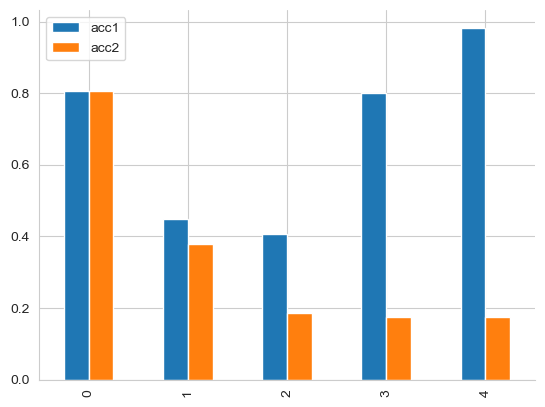

In [30]:
pd.DataFrame({"acc1": acc_by_output, "acc2": acc_up_to_out}).plot.bar()
sns.despine();

## Fine Tune VGG16 weights

In [31]:
vgg16.trainable = True
# Fine-tune from this layer onwards
start_fine_tuning_at = 1

# Freeze all the layers before the `fine_tune_at` layer
for layer in vgg16.layers[:start_fine_tuning_at]:
    layer.trainable = False

In [32]:
model.compile(optimizer="adam", loss=weighted_entropy, metrics=[weighted_accuracy])

In [33]:
fine_tune_epochs = 50
total_epochs = initial_epochs + fine_tune_epochs

In [36]:
result_fine_tune = model.fit(
    x=X_train,
    y=y_train,
    validation_split=0.1,
    batch_size=32,
    epochs=total_epochs,
    initial_epoch=result.epoch[-1],
    callbacks=[early_stopping],
)

Epoch 16/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 260s 272ms/step - loss: 1.3738 - weighted_accuracy: 0.5730 - val_loss: 1.2907 - val_weighted_accuracy: 0.5803
Epoch 17/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 263s 280ms/step - loss: 1.0424 - weighted_accuracy: 0.6446 - val_loss: 2.4978 - val_weighted_accuracy: 0.4481
Epoch 18/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 266s 283ms/step - loss: 0.9231 - weighted_accuracy: 0.6750 - val_loss: 0.8861 - val_weighted_accuracy: 0.6922
Epoch 19/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 258s 275ms/step - loss: 0.8200 - weighted_accuracy: 0.7053 - val_loss: 1.5377 - val_weighted_accuracy: 0.5803
Epoch 20/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 259s 275ms/step - loss: 0.7223 - weighted_accuracy: 0.7436 - val_loss: 0.7677 - val_weighted_accuracy: 0.7335
Epoch 21/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 261s 278ms/step - loss: 0.6082 - weighted_accuracy: 0.7866 - val_loss: 0.7471 - val_weighted_accuracy: 0.7570
Epoch 22/66
940/940 ━━━━━━━━━━━━━━━━━━━━ 262s 279ms/step - loss: 0.4948 - weighted_accuracy: 0

In [38]:
metrics_tuned = pd.concat([metrics,
    pd.DataFrame(result_fine_tune.history)], ignore_index=True
)

In [39]:
metrics_tuned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   loss                   58 non-null     float64
 1   val_loss               58 non-null     float64
 2   val_weighted_accuracy  58 non-null     float64
 3   weighted_accuracy      58 non-null     float64
dtypes: float64(4)
memory usage: 1.9 KB


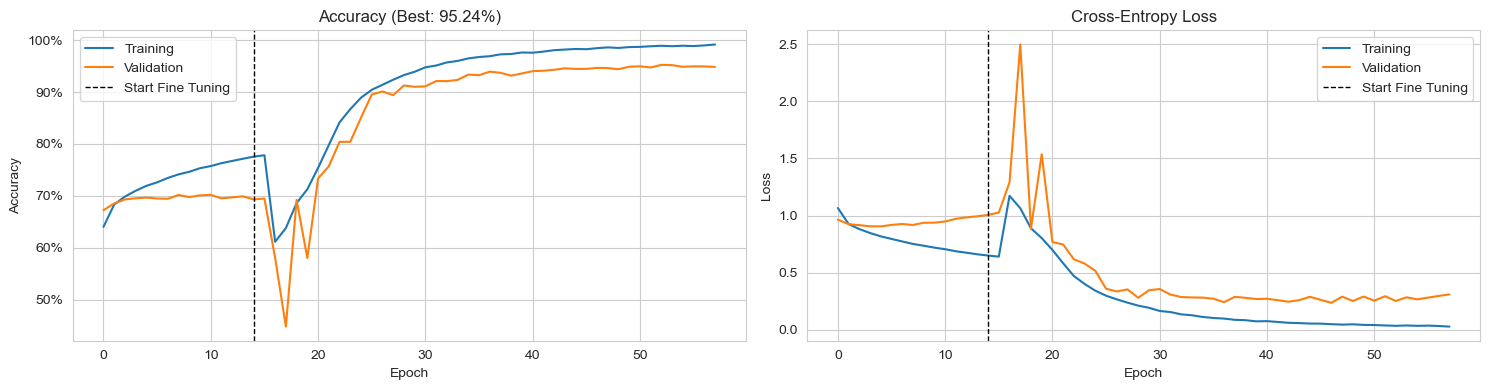

In [40]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 4))
metrics_tuned[["loss", "val_loss"]].plot(ax=axes[1], title="Cross-Entropy Loss")
metrics_tuned[["weighted_accuracy", "val_weighted_accuracy"]].plot(
    ax=axes[0],
    title=f"Accuracy (Best: {metrics_tuned.val_weighted_accuracy.max():.2%})",
)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:.0%}".format(y)))
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Loss")
for ax in axes:
    ax.axvline(14, ls="--", lw=1, c="k")
    ax.legend(["Training", "Validation", "Start Fine Tuning"])
    ax.set_xlabel("Epoch")
fig.tight_layout()
fig.savefig(results_path / "transfer_learning_svhn");